In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import scipy
from scipy import linalg
from scipy import stats
from pylab import * 
%matplotlib inline
from scipy.optimize import curve_fit

In [2]:
np.random.seed(9)

In [16]:
#M=1
N=100
T=50
e=.01 # si cambias e cambiar el titulo de las graficas 
q=1+e #para q esten mas separados los dos espectros
corr1=0.5# si cambias corr1 cambiar el titulo de las graficas de intesidades
corr2=0.5# si cambias corr2 cambiar el titulo de las graficas de intesidades
k1=250
k2=N-k1
W=[]
q1=q+1
M2 = np.zeros((T,N))
C = np.zeros((N,N))
Cdiag = np.zeros((N,N))
Cq = np.zeros((N,N))
Corr = np.zeros((N,N))
Corrsqr = np.zeros((N,N))
korr=np.zeros((N,N))
kq=np.zeros((N,N))

In [23]:
#### matriz wishart ####

M1 = 1 * np.random.randn(N, T) + 0
#print M1

####### normalizando el renglon ######
for i in xrange(N):
	mean=np.mean(M1[i])
	var=(np.var(M1[i]))**.5
	for j in xrange(T):
		M1[i][j]=(M1[i][j]-mean)/var
###### transpuesta #####
#for i in xrange(N):
#	for j in xrange(T):
#		M2[j][i] = M1[i][j]

In [18]:
###  matriz de Xi corr ###
for i in xrange(k1):
	for j in xrange(i,N):
		if i==j:
			Corr[i][j]=.8**(abs(i-j))
		else:
			Corr[i][j]=.8**(abs(i-j))
			Corr[j][i]=Corr[i][j]
for i in xrange(k1,N):
	for j in xrange(i,N):
		if i==j:
			Corr[i][j]=.8**(abs(i-j))
		else:
			Corr[i][j]=.8**(abs(i-j))
			Corr[j][i]=Corr[i][j]


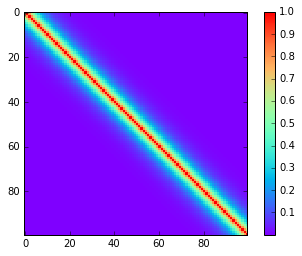

In [19]:
plt.imshow(Corr,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
plt.colorbar()


In [24]:
##### haciendo la matriz de corr(wishart correlacionado) ######
Corrsqr=np.real(scipy.linalg.sqrtm(Corr))


CorrsqrM1=np.dot(Corrsqr,M1)
#M2Corrsqr=np.dot(M2,Corrsqr)
M2Corrsqr=np.transpose(CorrsqrM1)

C=np.dot(CorrsqrM1,M2Corrsqr)
C=C/T
###### diagonalizando C #########
w, v = LA.eigh(C)
for i in w:
	W.append(i)

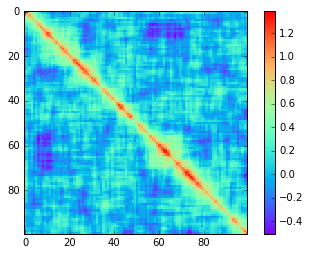

In [25]:
plt.imshow(C,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
plt.colorbar()

In [50]:
##### power mapping #####

for i in xrange(N):
    for j in xrange(i,N):
        XX=C[i][j]
        Cq[i][j]= (abs(XX)**q1)/XX
        Cq[j][i] = Cq[i][j]

### diagonalizando Cq ###
W1=[]
w1, v1 = LA.eigh(Cq)

W1=w1

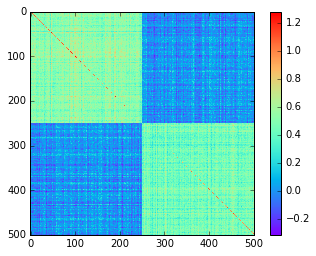

In [51]:
plt.imshow(Cq,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
plt.colorbar()

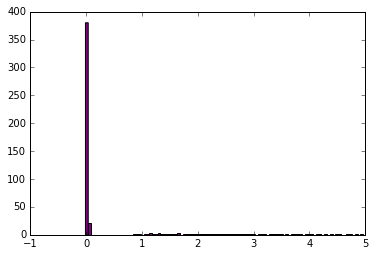

In [52]:
altura,bins,ignorar=plt.hist(w1[:498], 100, color="purple")

1.0


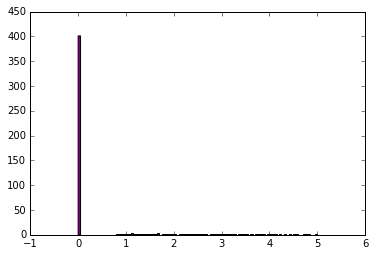

In [53]:

altura,bins,ignorar=plt.hist(w[:498], 100, color="purple")
print altura[-1]

In [57]:
#### calculando Intesidades ####
evector500=[]
ev=N-1
for i in xrange(0,N):
    evector500.append([])
    evector500[-1].append(v[:,ev][i]*v[:,ev][i])

evector499=[]
ev=498
for i in xrange(0,N):
    evector499.append([])
    evector499[-1].append(v[:,ev][i]*v[:,ev][i])

/home/jose/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:11: RuntimeWarning: divide by zero encountered in divide
/home/jose/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:11: RuntimeWarning: invalid value encountered in divide


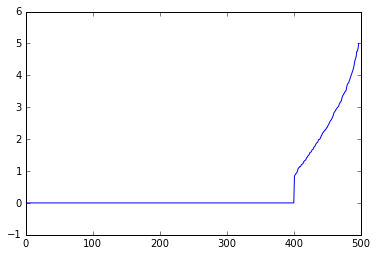

In [56]:
#checar si v estaban ordenados, plot de (C*v)/v 
vvec=v[:,N-10]
ww=w[N-10]
#print type(vvec)
mtv=np.dot(C,vvec)
mtv=mtv/vvec
todosv=[]
for i in xrange(N):
    vvec=v[:,i]
    mtv=np.dot(C,vvec)
    mtv=mtv/vvec
    todosv.append(mtv[1])
plt.plot(todosv[:N-2])

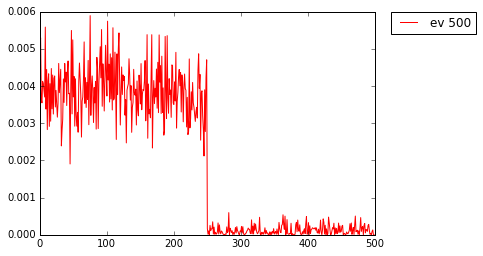

In [58]:
### plot los ultimos dos eigenvectors(intesidades)###
t1 = np.arange(0, N)
ev500,=plt.plot(t1,evector500, color="Red",label="ev 500")

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


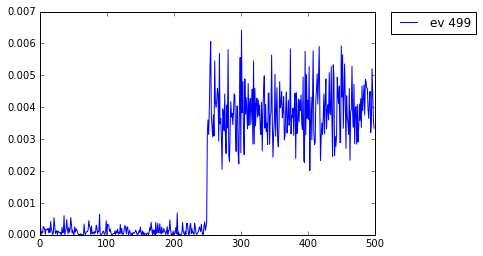

In [59]:
ev499,=plt.plot(t1,evector499, label="ev 499") 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

500


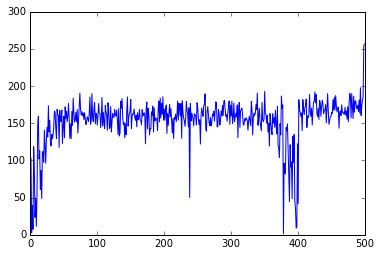

In [61]:
########## calculando lal intensidad (IPR)#########
evalue=[]
Inten=[]
I1=0

for i in xrange(N):
    I1=0
    Inten.append([])
    evalue.append(i)
    for j in xrange(N):
        I1+= ((v[:,i][j])**4)
       
    Inten[i].append(1/I1)
plt.plot(evalue,Inten, label="sin powermap")
#plt.xlim(5,500)
print N

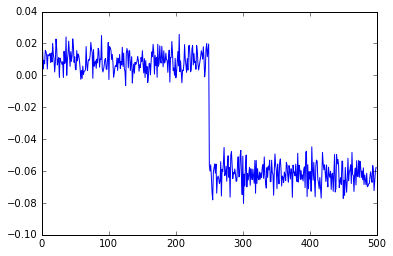

In [62]:
plt.plot(v1[:,N-2])
#altura,bins,ignorar=plt.hist(v[:,499], 40,normed=1, color="purple")

<Container object of 3 artists>

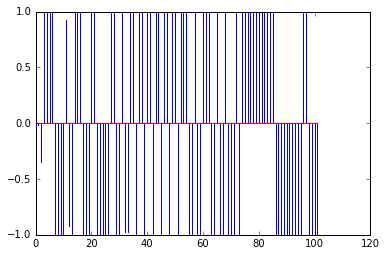

In [63]:
## producto punto entre evectores
evdot=np.zeros(N)
for i in xrange(N):
    evdot[i]=np.dot(v1[:,i],v[:,i])
fig, ax = plt.subplots()
ax.stem(evdot[398:], markerfmt=' ')
    

In [38]:
arr1= np.dot(v[:,N-100],v1[:,N-100])
print arr1

-0.133390841826


<Container object of 3 artists>

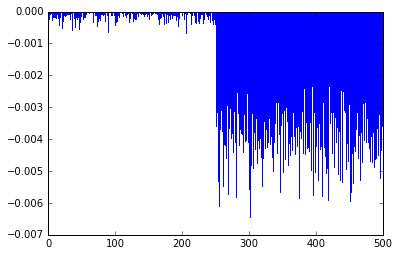

In [64]:
## multiplicando cada componente del evector con PM con su correspondiente evector sin PM
compEv=np.zeros(N)
x=N-2
for i in xrange(N):
    compEv[i]=(np.dot(v1[:,x][i],v[:,x][i]))
    
fig, ax = plt.subplots()
ax.stem(compEv, markerfmt=' ')  
#plt.ylim(-.00005,.00005)

TypeError: map() requires at least two args

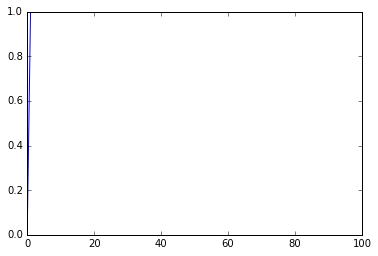

In [65]:
#n=300

suma=[]
for i in xrange(N):
    sumvv=0
    for j in xrange(N-T+1,N):
        v1v=np.dot(v1[:,i],v[:,j])
        sumvv+=(v1v)**2
    #print sumvv
    suma.append(sumvv)
    #print suma 
#print suma
plt.plot(suma[400:])
#print suma[257:]


map(lambda x: np.dot(x ,v[:,j]))

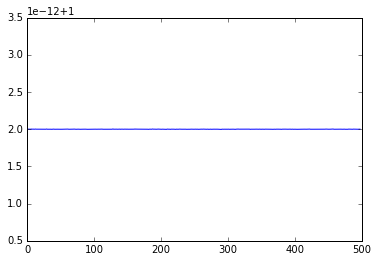

In [40]:
arr=np.zeros(N)
for i in xrange(N):
    sumvv=0
    for j in xrange(N):
        v1v=np.dot(v1[:,i],v[:,j])
        sumvv+=(v1v)**2
    arr[i]=sumvv
plt.plot(arr[:498])
#print arr

In [537]:
print len(compEv)

500


8.99459469637e-05
[ 0.38440644  0.01719663  1.05903288]


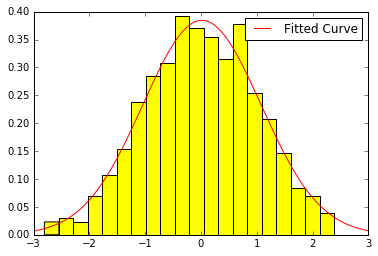

In [41]:
#### checando cual generador de numeros aleatorios es mejor 
M= 1 * np.random.randn(500) + 0.0
print np.mean(M)
altura,cajas,ignorar=plt.hist(M, 20, color = "yellow", normed=1, histtype='bar')

#### ajustando una gaussina
Centrocajas=np.zeros(len(altura))
ds=cajas[1]-cajas[0]
#    print ds
for i in xrange(0,len(cajas)-1):
    Centrocajas[i]=cajas[i]+ds/2
#model function
def f(x, a, b,c):
    return a*np.exp(-((x-b)**2)/(2*c**2))
# Do the fit
popt, pcov = curve_fit(f, Centrocajas, altura, [1.0, 1.0,1.0])
# Plot data


# Plot fit curve
fit_x = np.linspace(-3, 3, 200) 
plt.plot(fit_x, f(fit_x, *popt),'r-', label="Fitted Curve")
plt.legend()
print popt

-0.043274986282


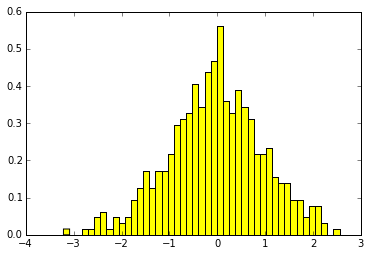

In [539]:
#### checando cual generador de numeros aleatorios es mejor 
aa=np.random.normal(0, 1, 500)
#print a
print np.mean(aa)
a,b,c=plt.hist(aa, 45, color = "yellow", normed=1, histtype='bar')

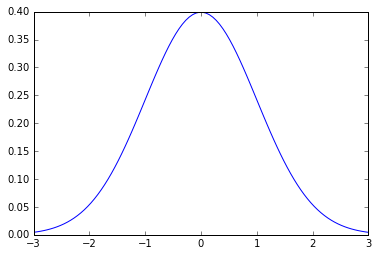

In [42]:
### plot una gaussiana 
mean = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(-3,3,100)
plt.plot(x,mlab.normpdf(x,mean,sigma))

-1.3855245173e-05
-1.3855245173e-05
1.0
-1294.21290298
1559023.33952
-0.115757904471
6.23653141027


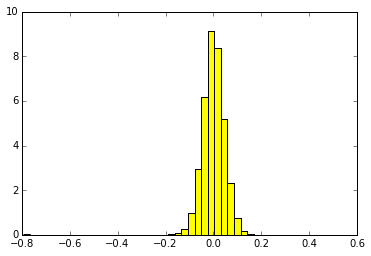

In [514]:
#### histograma eigenvector ##
evec=[]
II=0
for i in xrange(200,301):
    for j in xrange(N):
        evec.append(v[:,i][j]) 
a,b,c=plt.hist(evec, 45, color = "yellow", normed=1, histtype='bar')
m1=np.mean(evec)
mm=0
mm2=0
mm3=0
mm4=0
xx=[]
#print len(evec)
vari=np.var(evec)
for num in xrange(0,len(evec)):
    mm += evec[num]
mm = mm/len(evec)
for n in xrange(0,len(evec)):
    xx.append((evec[n]*evec[n]))
    mm2 += xx[n]
mm2 = mm2/101
for num in xrange(0,len(evec)):
    mm3 += ((evec[num]-m1)**3)/vari**3
mm3 = mm3/len(evec)
for num in xrange(0,len(evec)):
    mm4 += ((evec[num]-m1)**4)/len(evec)
mm4 = mm4/vari**4
print m1
print mm
print mm2 
print mm3 
print mm4
skew=stats.skew(evec)
kurt=scipy.stats.kurtosis(evec,0,False,False)
print skew
print kurt
#print "a=",a, "b =",b
#plt.xlim(.09)
#plt.ylim(0,2.5)

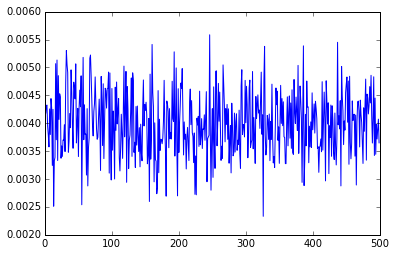

In [515]:
####
ev500y499=[]
ev=499
ev1=498
for i in xrange(0,N):
    ev500y499.append([])
    zz=(v[:,ev][i]**2 + (v[:,ev1][i])**2)
    ev500y499[-1].append(zz)
plt.plot(t1,ev500y499)
#plt.show()